Quick study to check how much energy is encapsulated across differing R values for DEP region

In [1]:
import os, sys
sys.path.append('../')

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from pathlib import Path
import importlib

import FOM_functions      as FOM
import cutting_functions  as cutf
import fitting_functions  as fitf
import plotting_functions as plotf

importlib.reload(FOM)
importlib.reload(cutf)
importlib.reload(fitf)



/home/e78368jw/miniconda3/envs/IC-3.13-2026-05-21/lib/python3.13/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


<module 'fitting_functions' from '/home/e78368jw/Documents/NEXT_CODE/next_misc/new_FOM_method/testing/../fitting_functions.py'>

In [2]:
# visualisation params
plt.rcParams.update({
    # Use LaTeX for text rendering
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes (match your LaTeX doc's font size)
    "font.size": 12*2,
    "axes.titlesize": 22*2,
    "axes.labelsize": 22*2,
    "xtick.labelsize": 20*2,
    "ytick.labelsize": 20*2,
    "legend.fontsize": 18*2,

    # Figure size — match LaTeX text width
    # For A4 with default margins: ~6.3in wide
    "figure.figsize": (12.6, 10),  # golden ratio height

    # Line/marker quality
    "lines.linewidth": 3.0,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})


In [3]:
# load in data
timestamp = '456015'
#data = pd.read_hdf(f'/home/e78368jw/Documents/topology_data/p_scan_140526_3sigma/{timestamp}/full_dataset_15589_15590_15591_15592_15593_15594_15596_15597_{timestamp}.h5', 'Tracking/Tracks') 
data = pd.read_hdf(f'/home/e78368jw/Documents/topology_data/p_scan_140526/{timestamp}/full_dataset_15589_15590_15591_15593_15594_{timestamp}.h5', 'Tracking/Tracks') 
display(data)

,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
0,3801498,0,1.466295,249.314697,412,970,1,-65.775,-0.875,749.814750,...,768.982559,-3.575,44.775,813.748853,0.435425,0.263727,0.0,14.380000,14.517647,13.617089
11,1556423,0,1.593040,219.540974,278,710,1,-204.725,-186.475,403.483375,...,421.119094,-50.225,-109.725,455.562835,0.555350,0.501672,0.0,14.575000,14.170833,13.848063
22,2335194,0,1.589335,179.527229,249,673,1,-126.975,75.875,197.231000,...,220.931227,-50.225,122.525,279.887646,0.691032,0.640770,0.0,13.954545,14.276923,14.346328
13,2130640,0,1.412268,256.847131,347,894,1,26.525,44.775,841.667750,...,994.685363,149.925,75.875,890.566908,0.531808,0.300295,0.0,14.170833,14.367857,14.426269
27,2798454,0,1.673739,281.979679,358,875,1,-34.675,-202.025,157.091000,...,231.221065,104.275,-155.375,308.940500,0.655274,0.168139,0.0,14.296429,14.453125,13.923063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,3187569,0,1.632569,190.033299,359,969,1,88.725,-47.525,746.388125,...,866.252937,165.475,29.225,782.471962,0.653753,0.422715,0.0,14.045455,14.045455,14.131864
1,3361232,0,1.690998,183.124444,353,964,1,-112.425,-217.575,977.920750,...,1011.839058,-19.125,-170.925,1012.342778,0.533263,0.530237,0.0,14.296429,14.517647,13.478700
0,1457260,0,1.587386,206.987196,385,988,1,-235.825,-202.025,345.336375,...,381.435531,-142.525,-47.525,390.486622,0.584859,0.269674,0.0,14.170833,14.453125,14.416906
7,2803094,0,1.498167,371.615340,281,640,1,26.525,-31.975,139.886500,...,174.713310,104.275,13.675,412.405074,0.716998,0.168322,0.0,13.895000,14.200000,14.797643


In [4]:
lower_z = 20
upper_z = 1195
r_lim   = 300
lower_e = 1.4
upper_e = 1.8

data, _ = cutf.apply_cuts(data, lower_z, upper_z, r_lim, lower_e, upper_e)

Cutting events around fiducial volume related to:
Z range between 20 and 1195
Radius range < 300
Fiducial track cut
Relative Cut efficiency:
Efficiency: 100.00 %
Absolute Cut efficiency:
Efficiency: 100.00 %
One track cut
Relative Cut efficiency:
Efficiency: 99.80 %
Absolute Cut efficiency:
Efficiency: 99.80 %
Blob overlap cut
Relative Cut efficiency:
Efficiency: 100.00 %
Absolute Cut efficiency:
Efficiency: 100.00 %
Energy cut
Relative Cut efficiency:
Efficiency: 100.00 %
Absolute Cut efficiency:
Efficiency: 100.00 %


In [17]:
# apply blob cut to remove background
data = data[data.eblob2 > 0.37]

39.57231366252227
1172.7173682886253
[  39.57231366  152.88681913  266.20132459  379.51583005  492.83033551
  606.14484098  719.45934644  832.7738519   946.08835736 1059.40286283
 1172.71736829]


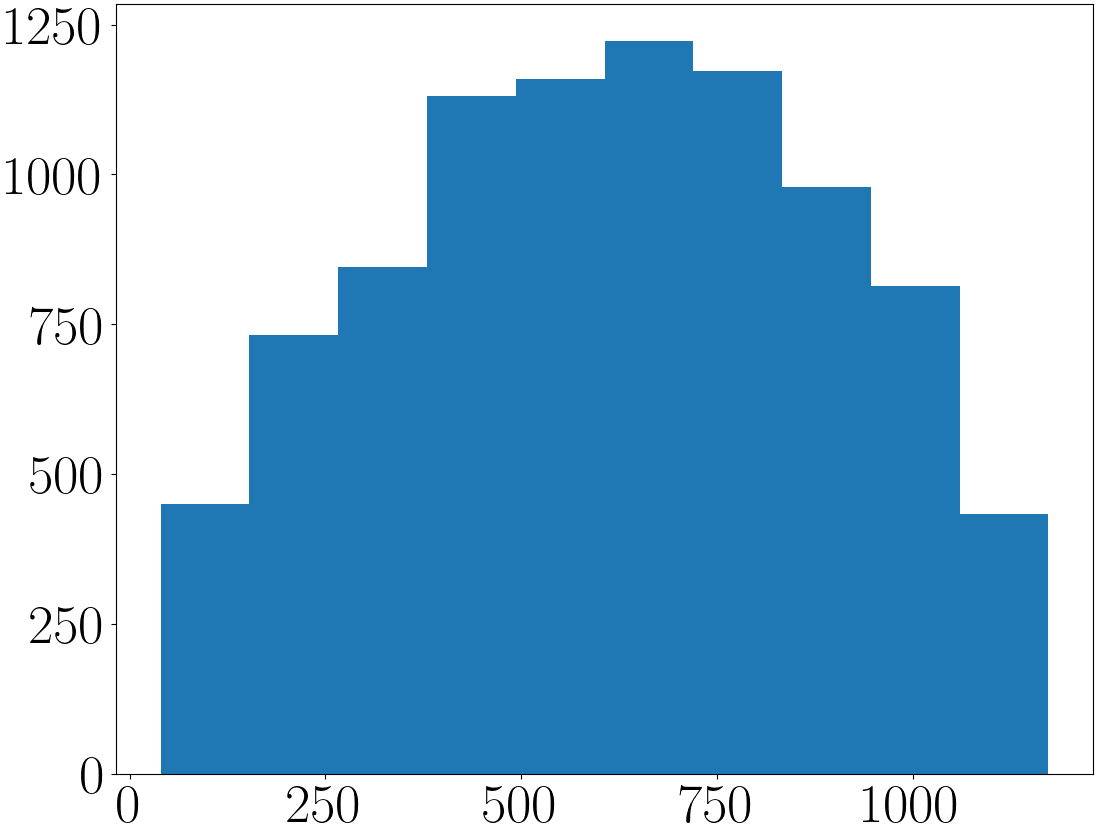

In [18]:
# separate into Z slices based on blob position, lets choose the energetic blobs
print(data.blob1_z.min())
print(data.blob1_z.max())
heights, bins, _ = plt.hist(data.blob1_z.values)
print(bins)

In [46]:
dfs = {}

for i, vals in enumerate(bins):
    if i == 0:
        pass
    else:
        dfs[f'{vals_m1:.2f} - {vals:.2f}'] = data[(data.blob1_z > vals_m1) & (data.blob1_z <= vals)]
    vals_m1 = vals

In [47]:
dfs.keys()

dict_keys(['39.57 - 152.89', '152.89 - 266.20', '266.20 - 379.52', '379.52 - 492.83', '492.83 - 606.14', '606.14 - 719.46', '719.46 - 832.77', '832.77 - 946.09', '946.09 - 1059.40', '1059.40 - 1172.72'])

In [48]:
dfs['39.57 - 152.89']

,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
25,2491889,0,1.572081,170.636333,219,533,1,10.975,-170.925,25.939500,...,61.735566,73.175,-124.275,93.403575,0.854694,0.578029,0.0,14.087500,14.367857,14.523563
13,517952,0,1.592222,210.070733,247,662,1,-204.725,-139.825,101.005750,...,137.393967,-173.625,-16.425,139.005668,0.685094,0.546781,0.0,14.515625,14.200000,14.987975
14,805358,0,1.575551,235.527150,275,721,1,-34.675,-233.125,88.647125,...,109.372871,57.625,-124.275,235.673834,0.596296,0.467311,0.0,13.895000,14.200000,14.035750
17,2639862,0,1.585212,185.857639,276,709,1,119.825,-31.975,57.090875,...,92.449563,181.025,13.675,133.484438,0.730603,0.623508,0.0,13.711111,14.453125,13.988969
6,2485309,0,1.590093,258.956197,265,652,1,42.075,-202.025,32.243500,...,95.271076,73.175,-31.975,63.877542,0.561842,0.494070,0.0,14.446667,14.517647,13.663393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1314586,0,1.572123,198.628491,247,640,1,-50.225,-186.475,80.645750,...,111.525625,-3.575,-124.275,172.789240,0.584139,0.506582,0.0,14.453125,13.895000,14.318906
0,635341,0,1.602599,210.771537,256,668,1,-96.875,-94.175,94.195625,...,128.206461,42.075,-0.875,161.498000,0.739317,0.598979,0.0,14.446667,14.045455,14.043357
5,1948009,0,1.543422,331.772285,275,670,1,-173.625,-139.825,23.173125,...,55.119360,-126.975,-0.875,268.885861,0.667686,0.396408,0.0,14.045455,14.296429,14.615354
5,3841817,0,1.583487,255.869966,269,575,1,-142.525,-202.025,22.361250,...,42.263739,-112.425,-31.975,115.271013,0.647016,0.525102,0.0,14.453125,14.575000,13.720514


In [59]:
test_str = '39.57 - 152.89'
print(float(test_str.split('-')[0]))
print(float(test_str.split('-')[1]))
print([float(x) for x in test_str.split('-')])

39.57
152.89
[39.57, 152.89]


In [60]:
# extract average blob1 energy from each dictionary
b1_energies = []
z_positions = []
for key, item in dfs.items():
    # take average position for Z by extracting the two numbers around the value
    z_positions.append(np.mean(np.array([float(x) for x in key.split('-')])))
    b1_energies.append(item.eblob1.mean())
    
    

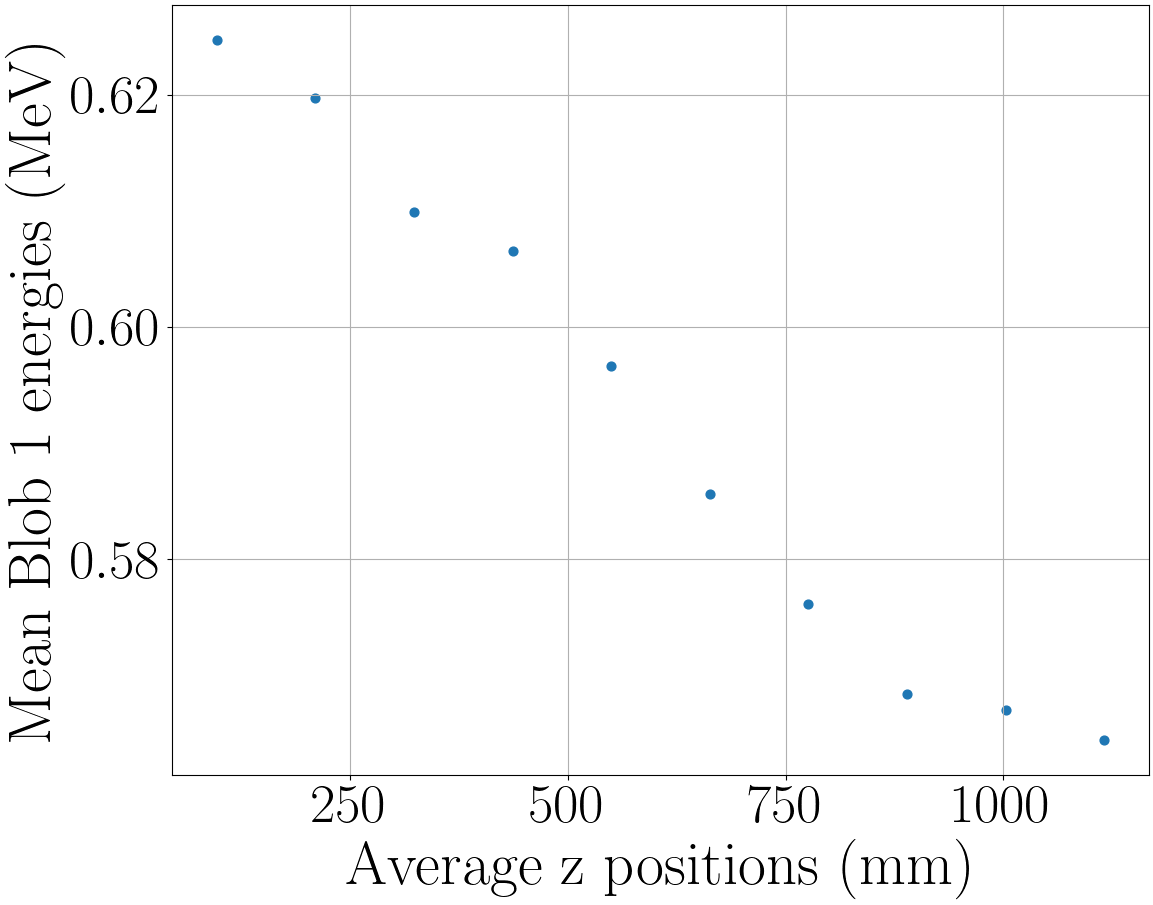

In [67]:
plt.scatter(z_positions, b1_energies, s = 40)
plt.grid()
plt.ylabel('Mean Blob 1 energies (MeV)')
plt.xlabel('Average z positions (mm)')
plt.show()